# CtfPFN: counterfactual PFN validation

Validates the counterfactual PFN family against a toy linear SCM with correlated Gaussian noises (an unobserved confounder). The SCM:

$$Z \sim \mathcal{N}(0, I_d), \quad X = \tanh(a_{xz}^\top Z + \epsilon_x), \quad Y = \tanh(\beta\,X' + \gamma^\top Z + \epsilon_y),$$

with $(\epsilon_x, \epsilon_y)$ jointly Gaussian with correlation $\rho \neq 0$. Setting $X' = X$ gives the observational outcome; varying $X'$ gives unit-level counterfactuals.

ETT counterfactual posterior (pre-tanh latent space):
$$\epsilon_x = \mathrm{atanh}(x) - a_{xz}^\top z, \qquad \epsilon_y \mid \epsilon_x \sim \mathcal{N}\!\Big(\rho\,\tfrac{\sigma_y}{\sigma_x}\,\epsilon_x,\ \sigma_y^2(1-\rho^2)\Big),$$
$$Y_{x'} \mid z, x \;=\; \tanh\!\Big(\beta x' + \gamma^\top z + \epsilon_y\Big).$$

Checks:
1. **Smoke test** — shapes pass through and loss decreases.
2. **Mask correctness** — `~ctf_fraction` of rows contribute gradient.
3. **Factual sanity** — at $X' = X$, family means cluster on the analytical mean.
4. **Counterfactual fan-out** — at $X' \neq X$, family means disagree.
5. **Coverage** — analytical ETT lies inside the family envelope on most test units.
6. **Falsification** — if family std at $X' \neq X$ is near zero, random init alone is insufficient.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from model import NanoTabPFNModel
from riemann import RiemannDistribution
from ctf_prior import LinearSCMCtfPriorDataLoader, uniform_boundaries
from train_ctf import train_ctf_family, set_randomness_seed, get_default_device
from ctf_model import CtfPFNFamily

device = get_default_device()
print('device:', device)

device: mps


## 1. Toy SCM setup and analytical oracle

In [2]:
# Fixed toy SCM
D_Z = 2
TRUE_PARAMS = dict(
    a_xz=np.array([0.5, 0.4], dtype=np.float64),
    beta=0.7,
    gamma=np.array([0.3, -0.2], dtype=np.float64),
    rho=0.6,
    sigma_x=0.5,
    sigma_y=0.5,
)

def sample_scm(n, seed=0, params=TRUE_PARAMS):
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal((n, D_Z))
    eps1 = rng.standard_normal(n)
    eps2 = rng.standard_normal(n)
    e_x = params['sigma_x'] * eps1
    e_y = params['sigma_y'] * (params['rho'] * eps1 + np.sqrt(1 - params['rho']**2) * eps2)
    X = np.tanh(Z @ params['a_xz'] + e_x)
    Y = np.tanh(params['beta'] * X + Z @ params['gamma'] + e_y)
    return Z.astype(np.float32), X.astype(np.float32), Y.astype(np.float32)

def analytical_ctf(Z, X_obs, X_prime, params=TRUE_PARAMS, n_mc=20000, seed=123):
    """True ETT counterfactual moments under the SCM at the given parameters.

    Returns (mean, lo, hi) arrays of shape (n,) for a 95% CI by MC.
    """
    rng = np.random.default_rng(seed)
    Z = np.asarray(Z, dtype=np.float64)
    X_obs = np.clip(np.asarray(X_obs, dtype=np.float64), -0.9999, 0.9999)
    X_prime = np.asarray(X_prime, dtype=np.float64)
    e_x = np.arctanh(X_obs) - Z @ params['a_xz']
    mu = params['beta'] * X_prime + Z @ params['gamma'] + params['rho'] * params['sigma_y'] / params['sigma_x'] * e_x
    sd = params['sigma_y'] * np.sqrt(1 - params['rho']**2)
    eps = rng.standard_normal(n_mc)
    samples = np.tanh(mu[:, None] + sd * eps[None, :])
    mean = samples.mean(axis=1)
    lo = np.quantile(samples, 0.025, axis=1)
    hi = np.quantile(samples, 0.975, axis=1)
    return mean.astype(np.float32), lo.astype(np.float32), hi.astype(np.float32)

# sanity
Z_, X_, Y_ = sample_scm(4, seed=1)
m, lo, hi = analytical_ctf(Z_, X_, X_)  # factual
print('SCM sample Y      :', Y_)
print('analytical factual mean :', m)
print('-> agreement at X\'=X is by design (same e_y; tanh of Gaussian centered at correct location).')

SCM sample Y      : [0.16828091 0.23421702 0.3765425  0.28151014]
analytical factual mean : [0.38933533 0.2624708  0.4792752  0.0455162 ]
-> agreement at X'=X is by design (same e_y; tanh of Gaussian centered at correct location).


## 2. Train a family of K CtfPFNs

Smaller settings to keep CPU runtime reasonable. Bump `K`, `NUM_STEPS`, and model width for sharper results.

In [3]:
K_FAMILY = 5
NUM_STEPS = 1500
BATCH_SIZE = 8
N_PER_DATASET = 120
NUM_BUCKETS = 60
EMBEDDING_SIZE = 64
NUM_LAYERS = 3
NUM_HEADS = 4
MLP_HIDDEN = 128
CTF_FRACTION = 0.5  # 50% counterfactual rows during training (loss masked)

boundaries = uniform_boundaries(NUM_BUCKETS, lo=-1.0, hi=1.0)
riemann = RiemannDistribution(boundaries)

def prior_factory(seed):
    set_randomness_seed(seed + 10000)  # offset so prior streams differ from model init
    return LinearSCMCtfPriorDataLoader(
        num_steps=NUM_STEPS,
        batch_size=BATCH_SIZE,
        n_per_dataset=N_PER_DATASET,
        d_z=D_Z,
        ctf_fraction=CTF_FRACTION,
        n_train_min=N_PER_DATASET // 3,
        n_train_max=2 * N_PER_DATASET // 3,
        device=device,
    )

def model_factory(seed):
    set_randomness_seed(seed)
    return NanoTabPFNModel(
        embedding_size=EMBEDDING_SIZE,
        num_attention_heads=NUM_HEADS,
        mlp_hidden_size=MLP_HIDDEN,
        num_layers=NUM_LAYERS,
        num_outputs=NUM_BUCKETS,
    )

models = train_ctf_family(
    K=K_FAMILY,
    prior_factory=prior_factory,
    model_factory=model_factory,
    riemann=riemann,
    seeds=list(range(K_FAMILY)),
    lr=2e-3,
    device=device,
    steps_per_eval=300,
    verbose=True,
)
family = CtfPFNFamily(models, riemann, device=device, d_z=D_Z)

=== Family member 1/5 (seed=0) ===
step   299 | time    42.9s | loss  3.9357 | factual_frac 0.54
step   599 | time    74.2s | loss  3.5623 | factual_frac 0.50
step   899 | time   104.7s | loss  3.5503 | factual_frac 0.49
step  1199 | time   136.0s | loss  3.3719 | factual_frac 0.47
step  1499 | time   166.8s | loss  3.1544 | factual_frac 0.50
=== Family member 2/5 (seed=1) ===
step   299 | time    30.3s | loss  3.9579 | factual_frac 0.54
step   599 | time    62.7s | loss  3.5773 | factual_frac 0.50
step   899 | time    90.9s | loss  3.4757 | factual_frac 0.49
step  1199 | time   120.8s | loss  3.3579 | factual_frac 0.47
step  1499 | time   150.4s | loss  3.1394 | factual_frac 0.50
=== Family member 3/5 (seed=2) ===
step   299 | time    32.0s | loss  3.9507 | factual_frac 0.54
step   599 | time    61.2s | loss  3.6054 | factual_frac 0.50
step   899 | time    89.5s | loss  3.5154 | factual_frac 0.49
step  1199 | time   117.4s | loss  3.3360 | factual_frac 0.47
step  1499 | time   146.5s 

## 3. Factual sanity check

On held-out factual data, all $K$ family members should predict close to the analytical observational mean. Family std at $X' = X$ should be small.

In [4]:
# Generate observational dataset
Z_obs, X_obs, Y_obs = sample_scm(150, seed=2024)
Z_train, X_train, Y_train = Z_obs[:100], X_obs[:100], Y_obs[:100]
Z_test, X_test, Y_test = Z_obs[100:], X_obs[100:], Y_obs[100:]

family.fit(Z_train, X_train, Y_train)

# Factual queries: X' = X_test
fact = family.predict_counterfactual_family(Z_test, X_test, X_test)
true_fact_mean, true_fact_lo, true_fact_hi = analytical_ctf(Z_test, X_test, X_test)

fact_mae = np.mean(np.abs(fact['ensemble_mean'] - true_fact_mean))
fact_std_mean = float(fact['family_std'].mean())
print(f'Factual ensemble-mean MAE vs analytical: {fact_mae:.4f}')
print(f'Factual family std (mean across test): {fact_std_mean:.4f}')
print(f'Discretization floor (~2/K): {2/NUM_BUCKETS:.4f}')

Factual ensemble-mean MAE vs analytical: 0.0780
Factual family std (mean across test): 0.0507
Discretization floor (~2/K): 0.0333


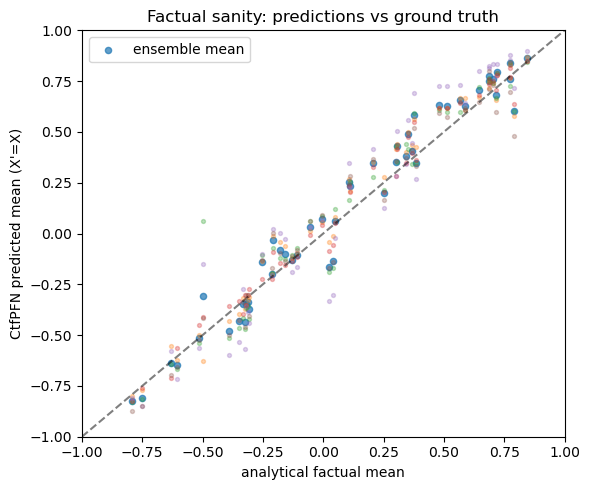

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(true_fact_mean, fact['ensemble_mean'], s=20, alpha=0.7, label='ensemble mean')
for k in range(family.K):
    ax.scatter(true_fact_mean, fact['means'][k], s=8, alpha=0.3)
lim = [-1, 1]
ax.plot(lim, lim, 'k--', alpha=0.5)
ax.set_xlabel('analytical factual mean')
ax.set_ylabel('CtfPFN predicted mean (X\'=X)')
ax.set_title('Factual sanity: predictions vs ground truth')
ax.set_xlim(lim); ax.set_ylim(lim); ax.legend()
plt.tight_layout(); plt.show()

## 4. Counterfactual fan-out

Sweep $X' \in [-1, 1]$ for a fixed $(z, x_{\text{obs}})$. The K family-mean curves should agree at $X' = x_{\text{obs}}$ and fan out away from it. The analytical ETT mean (at the true $\rho$) should lie within the spread.

/var/folders/rw/p478p4vn4vs5rggdh28zn3rc0000gn/T/ipykernel_7685/2859574377.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.axvline(float(x_i), color='k', linestyle='--', alpha=0.5, label=f'observed X={float(x_i):.2f}')


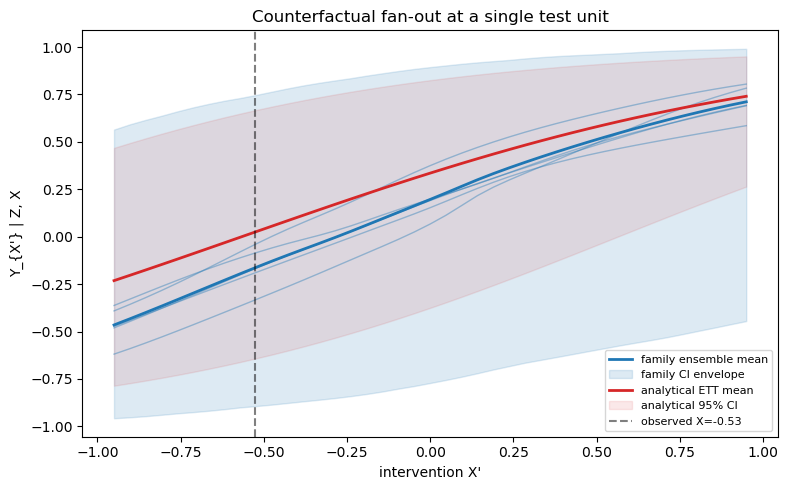

family std at X'=X_obs   : 0.1007
family std at extremes  : 0.0781


/var/folders/rw/p478p4vn4vs5rggdh28zn3rc0000gn/T/ipykernel_7685/2859574377.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dist = np.abs(x_grid - float(x_i))


In [6]:
# Pick a single test unit
i = 0
z_i = Z_test[i:i+1]; x_i = X_test[i:i+1]
x_grid = np.linspace(-0.95, 0.95, 41).astype(np.float32)
Z_rep = np.repeat(z_i, len(x_grid), axis=0)
X_rep = np.repeat(x_i, len(x_grid), axis=0)
fam = family.predict_counterfactual_family(Z_rep, X_rep, x_grid)
true_mean, true_lo, true_hi = analytical_ctf(Z_rep, X_rep, x_grid)

fig, ax = plt.subplots(figsize=(8, 5))
for k in range(family.K):
    ax.plot(x_grid, fam['means'][k], color='tab:blue', alpha=0.4, linewidth=1)
ax.plot(x_grid, fam['ensemble_mean'], color='tab:blue', linewidth=2, label='family ensemble mean')
ax.fill_between(x_grid, fam['envelope_lo'], fam['envelope_hi'], color='tab:blue', alpha=0.15, label='family CI envelope')
ax.plot(x_grid, true_mean, color='tab:red', linewidth=2, label='analytical ETT mean')
ax.fill_between(x_grid, true_lo, true_hi, color='tab:red', alpha=0.10, label='analytical 95% CI')
ax.axvline(float(x_i), color='k', linestyle='--', alpha=0.5, label=f'observed X={float(x_i):.2f}')
ax.set_xlabel("intervention X'")
ax.set_ylabel('Y_{X\'} | Z, X')
ax.set_title('Counterfactual fan-out at a single test unit')
ax.legend(loc='best', fontsize=8)
plt.tight_layout(); plt.show()

# Numerical fan-out: family std as a function of |X' - X_obs|
dist = np.abs(x_grid - float(x_i))
stds = fam['means'].std(axis=0)
print(f'family std at X\'=X_obs   : {stds[np.argmin(dist)]:.4f}')
print(f'family std at extremes  : {stds[np.argmax(dist)]:.4f}')

## 5. Coverage of the analytical counterfactual across many test units

For a grid of $X' \in [-1, 1]$ and held-out test units, count how often the analytical ETT mean lies inside the family envelope $[\text{envelope\_lo}, \text{envelope\_hi}]$ and how often inside the family-mean range $[\min_k \text{mean}_k, \max_k \text{mean}_k]$.

In [7]:
x_prime_grid = np.linspace(-0.9, 0.9, 9).astype(np.float32)
envelope_hits = 0; mean_range_hits = 0; total = 0
for x_p in x_prime_grid:
    Xp = np.full_like(X_test, x_p)
    fam = family.predict_counterfactual_family(Z_test, X_test, Xp)
    true_mean, _, _ = analytical_ctf(Z_test, X_test, Xp)
    envelope_hits += int(((true_mean >= fam['envelope_lo']) & (true_mean <= fam['envelope_hi'])).sum())
    mn = fam['means'].min(axis=0); mx = fam['means'].max(axis=0)
    mean_range_hits += int(((true_mean >= mn) & (true_mean <= mx)).sum())
    total += len(Z_test)

print(f'Coverage (analytical mean inside family envelope CI): {envelope_hits/total:.3f}')
print(f'Coverage (analytical mean inside family-mean range) : {mean_range_hits/total:.3f}')

Coverage (analytical mean inside family envelope CI): 1.000
Coverage (analytical mean inside family-mean range) : 0.504


## 6. Falsification: does family std grow with $|X' - X|$?

If the family disagrees only at $X' \neq X$, std should grow monotonically with $|X' - X|$. If it stays flat (or near zero), random-init alone is insufficient and a diversity regularizer would be needed.

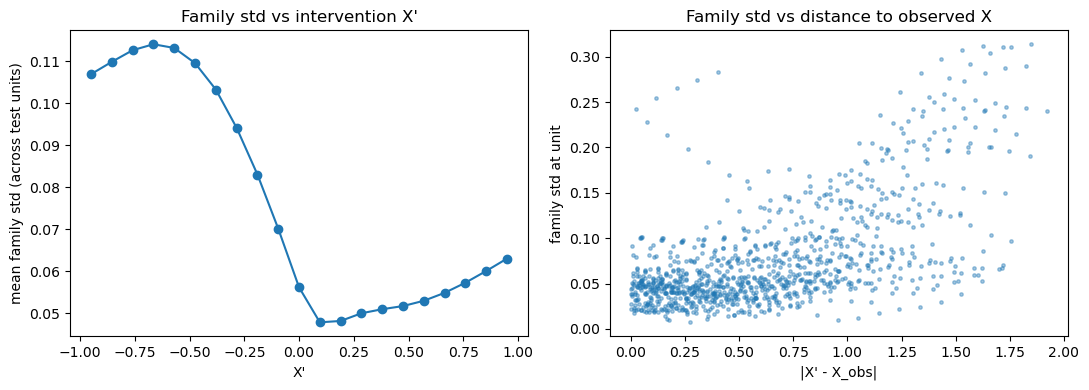

Spearman corr(|X' - X_obs|, family_std) = 0.544  (positive => fan-out as expected)


In [8]:
x_prime_grid = np.linspace(-0.95, 0.95, 21).astype(np.float32)
stds_per_xp = []
for x_p in x_prime_grid:
    Xp = np.full_like(X_test, x_p)
    fam = family.predict_counterfactual_family(Z_test, X_test, Xp)
    stds_per_xp.append(fam['family_std'].mean())
stds_per_xp = np.array(stds_per_xp)

# Plot family std vs distance to observed X
dist_to_obs = []
stds_by_unit = []
for x_p in x_prime_grid:
    Xp = np.full_like(X_test, x_p)
    fam = family.predict_counterfactual_family(Z_test, X_test, Xp)
    dist_to_obs.append(np.abs(X_test - x_p))
    stds_by_unit.append(fam['family_std'])
dist_to_obs = np.concatenate(dist_to_obs)
stds_by_unit = np.concatenate(stds_by_unit)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(x_prime_grid, stds_per_xp, 'o-')
axes[0].set_xlabel("X'")
axes[0].set_ylabel('mean family std (across test units)')
axes[0].set_title('Family std vs intervention X\'')
axes[1].scatter(dist_to_obs, stds_by_unit, s=6, alpha=0.4)
axes[1].set_xlabel("|X' - X_obs|")
axes[1].set_ylabel('family std at unit')
axes[1].set_title('Family std vs distance to observed X')
plt.tight_layout(); plt.show()

# Spearman-style monotonicity: correlation between distance and std
from scipy.stats import spearmanr
rho_sp, _ = spearmanr(dist_to_obs, stds_by_unit)
print(f'Spearman corr(|X\' - X_obs|, family_std) = {rho_sp:.3f}  (positive => fan-out as expected)')

## Notes

- Settings here are tuned for CPU. To get sharper results, increase `K_FAMILY`, `NUM_STEPS`, and the model width, and reduce `lr` toward 1e-4 for late-stage refinement.
- The analytical oracle uses the **true** SCM parameters; the family doesn't have access to them. The family converges to predictions consistent with the observational distribution — multiple SCMs are consistent with that distribution, so the spread is expected.
- If `Spearman corr` in §6 is small or negative, random-init diversity alone is insufficient on this prior. Adding a diversity regularizer that pushes family members apart on counterfactual queries (while keeping factual loss low) is the natural follow-up.